# 03 — Integration: Chemistry + Field + 16S

**Predictors (X):** influent/blend (3310, 3320) chemistry + field + microbes.  
**Outcome (Y):** `removal_3310_3340` (uses effluent dioxane).  
**3340 effluent:** saved in table for context — **never used as RF features** (downstream / leakage).

| | |
|--|--|
| **Y** | `removal_3310_3340` |
| **X** | `*_3310`, `*_3320` chemistry/field + microbes |
| **Excluded from X** | all `*_3340` columns (effluent is outcome side) |
| **Grain** | one row = one date |

**Inputs:** `bts_chemistry_field_by_date.csv` + `16S_genus_by_date_reactor.csv`  
**Output:** `integrated_plant_by_date.csv`

## Step 1 — Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import LeaveOneOut

%matplotlib inline
sns.set_theme(style="whitegrid")


def find_project_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "data" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not find project root.")


def is_effluent_col(col: str) -> bool:
    """TP-3340 = combined effluent (outcome side). Not valid as predictor."""
    return str(col).endswith("_3340")


PROJECT_ROOT = find_project_root()
PROC = PROJECT_ROOT / "data/processed"
CHEM_PATH = PROC / "bts_chemistry_field_by_date.csv"
MICRO_PATH = PROC / "16S_genus_by_date_reactor.csv"
OUT_PATH = PROC / "integrated_plant_by_date.csv"

Y_COL = "removal_3310_3340"
EXCLUDE_FROM_X = {"date", Y_COL}
FIELD_COLS = ["pH_3310", "temp_3310", "pH_3320", "temp_3320", "pH_3340"]
CHEM_CONTEXT = ["dioxane_3310", "dioxane_3320", "dioxane_3340"]

H1_GENERA = ["Nitrospira_D", "Nitrospira_A", "Nitrosocosmicus"]
H3_GENERA = ["Pseudonocardia"]

for p in (CHEM_PATH, MICRO_PATH):
    if not p.exists():
        raise FileNotFoundError(f"Run notebooks 01 & 02 first. Missing: {p}")

print("Project root:", PROJECT_ROOT)

Project root: /Users/shaivikoul/Documents/DIOPredict LOWRY


## Step 2 — Load & overlap audit

In [2]:
chem = pd.read_csv(CHEM_PATH, parse_dates=["date"])
micro = pd.read_csv(MICRO_PATH, parse_dates=["date"])

meta_micro = {"date", "reactor", "shannon", "richness"}
genus_cols = [c for c in micro.columns if c not in meta_micro]

dates_chem_y = set(chem.dropna(subset=[Y_COL])["date"].dt.normalize())
dates_micro = set(micro["date"].dt.normalize())
overlap = sorted(dates_chem_y & dates_micro)

print(f"Chemistry rows: {len(chem)}")
print(f"Dates with removal Y: {len(dates_chem_y)}")
print(f"16S (date, reactor) rows: {len(micro)}")
print(f"16S unique dates: {len(dates_micro)}")
print(f"\nOverlap dates (Y + microbes): {len(overlap)}")
for d in overlap:
    reactors = micro.loc[micro["date"] == d, "reactor"].tolist()
    print(f"  {d.date()}  reactors={reactors}")

Chemistry rows: 1245
Dates with removal Y: 1076
16S (date, reactor) rows: 12
16S unique dates: 10

Overlap dates (Y + microbes): 9
  2022-06-14  reactors=['R1']
  2023-02-28  reactors=['R1', 'R2']
  2023-10-03  reactors=['R1', 'R2']
  2025-01-07  reactors=['R1']
  2025-02-25  reactors=['R1']
  2025-04-01  reactors=['R1']
  2025-04-29  reactors=['R1']
  2025-06-24  reactors=['R1']
  2025-07-22  reactors=['R1']


## Step 3 — Build plant table (one row per date)

Microbes: **mean across reactors** sampled that day (R1-only in 2025 → same as R1 value).

In [3]:
# Plant-level microbe features: mean per date across reactors
micro_plant = (
    micro.groupby("date", as_index=False)[genus_cols + ["shannon", "richness"]]
    .mean()
    .rename(columns={"shannon": "shannon_mean", "richness": "richness_mean"})
)

rename_genus = {g: f"micro_{g}" for g in genus_cols}
micro_plant = micro_plant.rename(columns=rename_genus)
micro_feature_cols = list(rename_genus.values()) + ["shannon_mean", "richness_mean"]

integrated = chem.merge(micro_plant, on="date", how="inner")
integrated = integrated.dropna(subset=[Y_COL])
integrated = integrated.sort_values("date").reset_index(drop=True)
integrated = integrated.loc[:, ~integrated.columns.duplicated()]

effluent_cols = [c for c in integrated.columns if is_effluent_col(c)]

chem_feature_cols = [
    c
    for c in integrated.columns
    if c not in EXCLUDE_FROM_X
    and c not in micro_feature_cols
    and not is_effluent_col(c)
    and pd.api.types.is_numeric_dtype(integrated[c])
    and integrated[c].notna().any()
]

X_COLS = chem_feature_cols + micro_feature_cols
OUTCOME_COLS = [c for c in effluent_cols if c in integrated.columns]

print(f"Integrated plant rows: {len(integrated)}")
print(f"Influent/blend X (3310/3320): {len(chem_feature_cols)} chemistry/field cols")
print(f"Microbe X: {len(micro_feature_cols)}")
print(f"Total X features: {len(X_COLS)}")
print(f"Effluent 3340 cols (context only, NOT in X): {len(OUTCOME_COLS)}")
print(f"Date range: {integrated['date'].min().date()} → {integrated['date'].max().date()}")

integrated_2025 = integrated[integrated["date"].dt.year == 2025]
print(f"2025 rows: {len(integrated_2025)}")

preview = ["date", Y_COL, "sr_benzene_3310", "sr_tetrahydrofuran_3310", "field_nitrogen_ammonia_3310", "micro_Nitrospira_D"]
preview = [c for c in preview if c in integrated.columns]
print(integrated_2025[preview].head(10).to_string(index=False))

integrated.to_csv(OUT_PATH, index=False)
print(f"\nSaved: {OUT_PATH}")

Integrated plant rows: 9
Influent/blend X (3310/3320): 26 chemistry/field cols
Microbe X: 17
Total X features: 43
Effluent 3340 cols (context only, NOT in X): 128
Date range: 2022-06-14 → 2025-07-22
2025 rows: 6
      date  removal_3310_3340  sr_benzene_3310  sr_tetrahydrofuran_3310  field_nitrogen_ammonia_3310  micro_Nitrospira_D
2025-01-07          99.929032            950.0                  16000.0                        119.9            0.144738
2025-02-25          99.768293           1000.0                  27000.0                        106.2            0.172323
2025-04-01          99.750000            740.0                  22000.0                        146.2            0.139389
2025-04-29          99.701754            870.0                  18000.0                        253.0            0.210747
2025-06-24          99.792453           1100.0                  28000.0                        219.0            0.228310
2025-07-22          99.768182           1000.0                

## Step 4 — H1–H3 exploratory plots

H1 — Nitrifiers vs removal


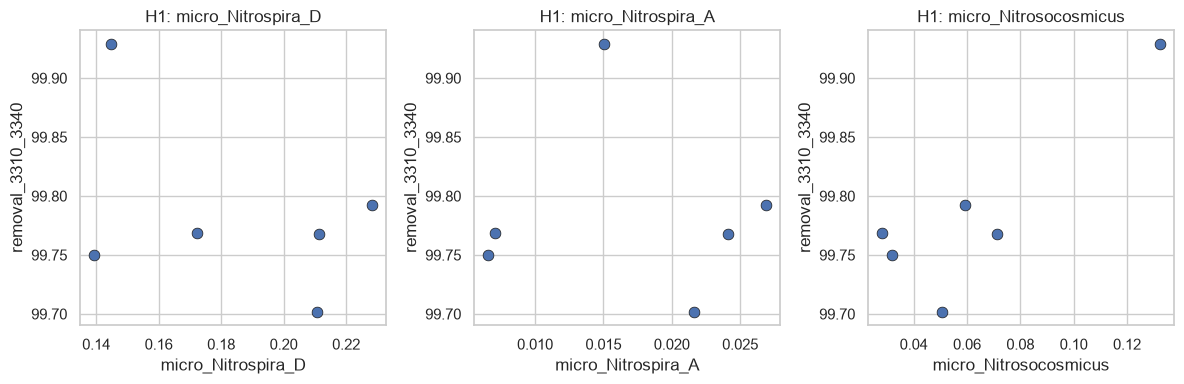

H2 — Diversity vs removal


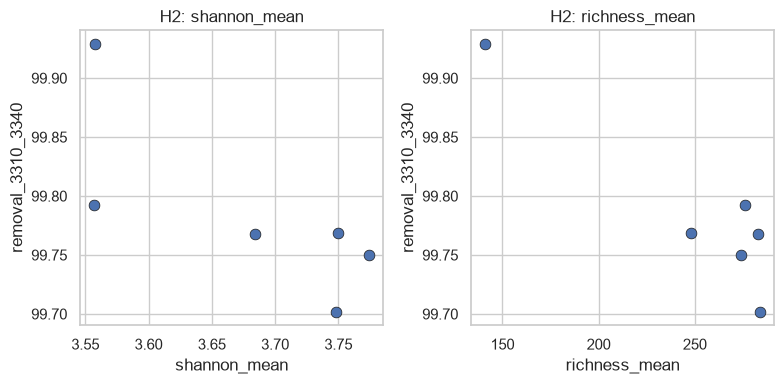

H3 — Putative degraders vs removal


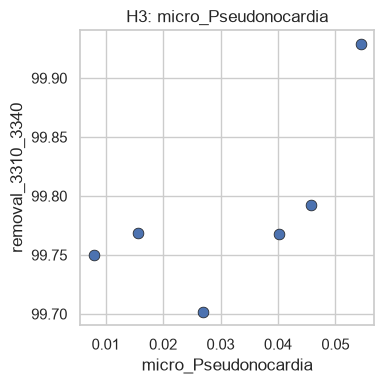

Field env vs removal


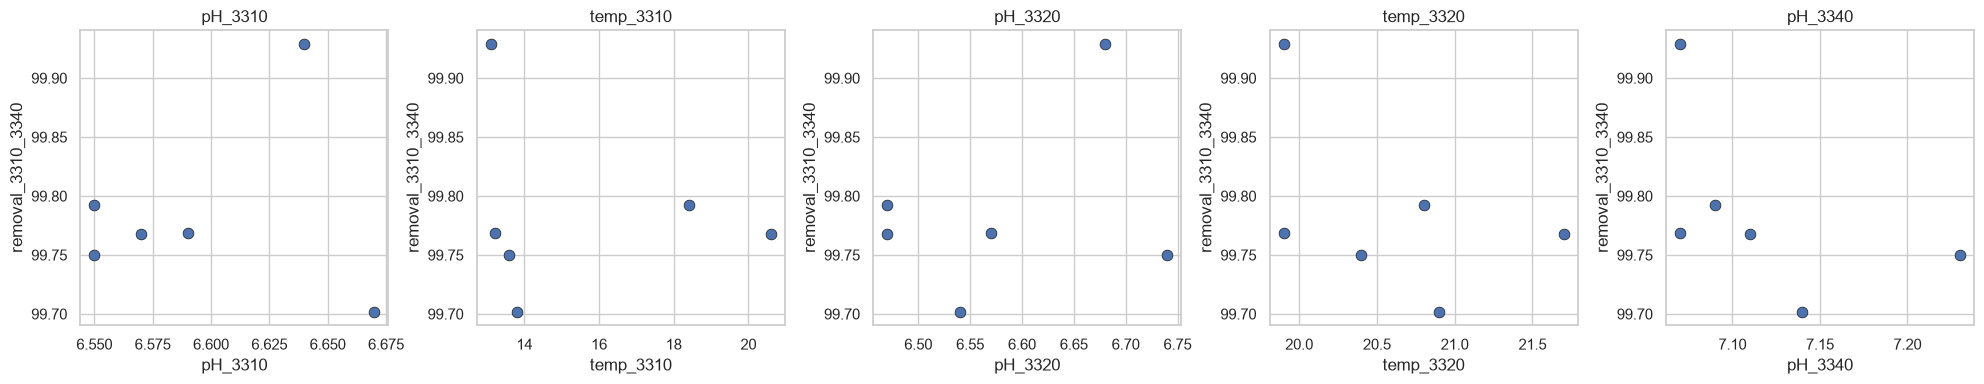

Influent chemistry vs removal


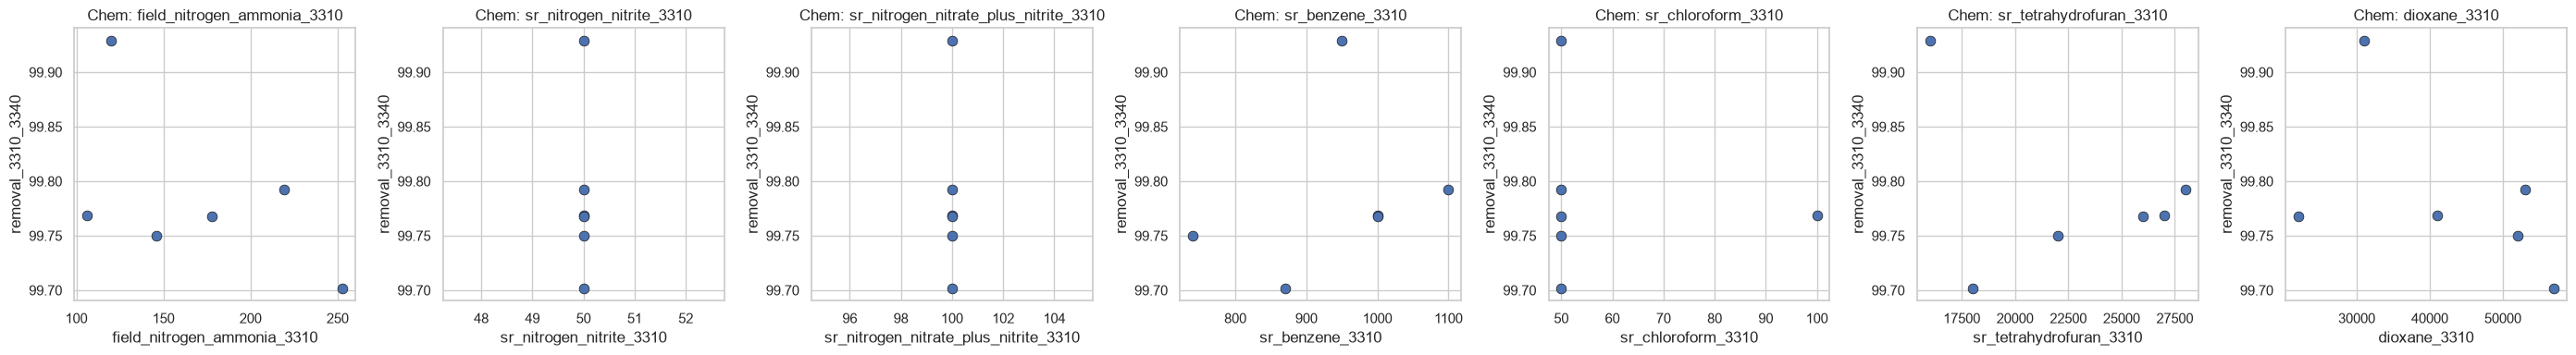

In [4]:
def scatter_y_vs_features(df, feature_cols, title_prefix=""):
    cols = list(dict.fromkeys(c for c in feature_cols if c in df.columns))
    if not cols or df.empty:
        print(f"No data for {title_prefix}")
        return
    n = len(cols)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, cols):
        sub = df[[col, Y_COL]].dropna()
        if sub.empty:
            ax.set_title(f"{title_prefix}{col} (no data)")
            continue
        ax.scatter(sub[col], sub[Y_COL], s=60, edgecolor="k", linewidth=0.5)
        ax.set_xlabel(col)
        ax.set_ylabel(Y_COL)
        ax.set_title(f"{title_prefix}{col}")
    plt.tight_layout()
    plt.show()


plot_df = integrated_2025 if len(integrated_2025) >= 3 else integrated

print("H1 — Nitrifiers vs removal")
scatter_y_vs_features(plot_df, [f"micro_{g}" for g in H1_GENERA], "H1: ")

print("H2 — Diversity vs removal")
scatter_y_vs_features(plot_df, ["shannon_mean", "richness_mean"], "H2: ")

print("H3 — Putative degraders vs removal")
scatter_y_vs_features(plot_df, [f"micro_{g}" for g in H3_GENERA], "H3: ")

print("Field env vs removal")
scatter_y_vs_features(plot_df, FIELD_COLS)

# Co-contaminants + nitrogen (3310 influent) vs removal
COCONTAM_COLS = [
    c for c in [
        "field_nitrogen_ammonia_3310",
        "sr_nitrogen_nitrite_3310",
        "sr_nitrogen_nitrate_plus_nitrite_3310",
        "sr_benzene_3310",
        "sr_chloroform_3310",
        "sr_tetrahydrofuran_3310",
        "dioxane_3310",
    ]
    if c in plot_df.columns
]
if COCONTAM_COLS:
    print("Influent chemistry vs removal")
    scatter_y_vs_features(plot_df, COCONTAM_COLS, "Chem: ")

## Step 5 — Correlation heatmap (X vs Y)

Correlation heatmap: top 30 features by |r| with removal_3310_3340


/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/shaivikoul/Documents/DIOPredict LOWRY/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


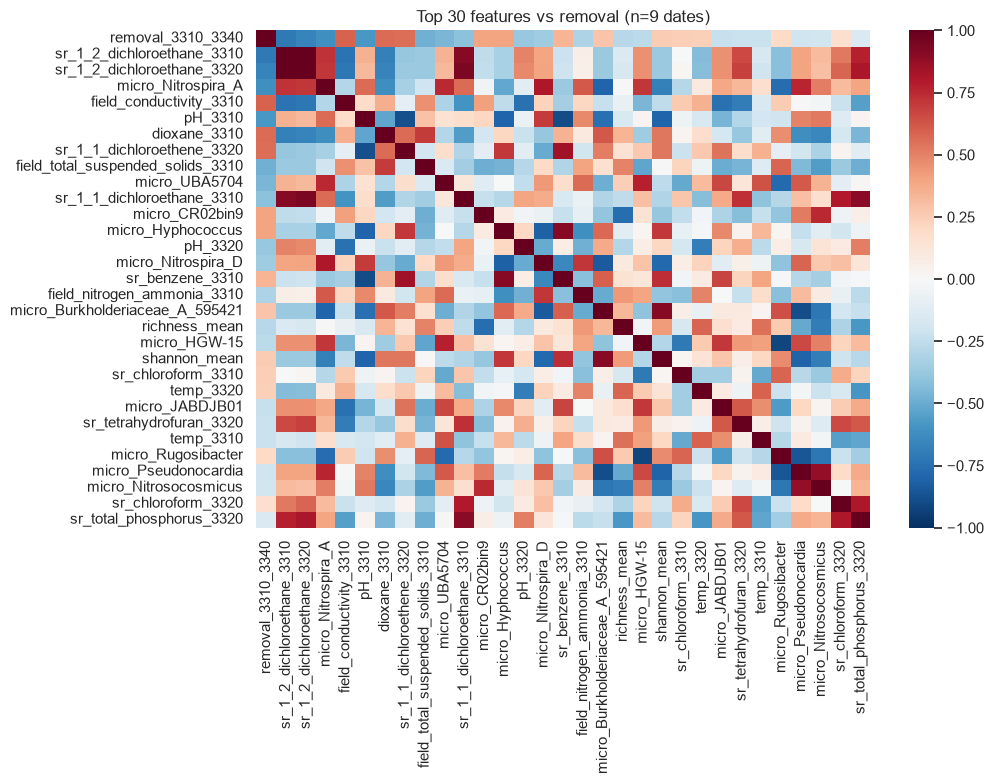


Top 15 Pearson r with removal_3310_3340:
  sr_1_2_dichloroethane_3310                    r=-0.715  n=9
  sr_1_2_dichloroethane_3320                    r=-0.667  n=9
  micro_Nitrospira_A                            r=-0.610  n=9
  field_conductivity_3310                       r=+0.590  n=9
  pH_3310                                       r=-0.582  n=9
  dioxane_3310                                  r=+0.563  n=9
  sr_1_1_dichloroethene_3320                    r=+0.559  n=9
  field_total_suspended_solids_3310             r=-0.477  n=8
  micro_UBA5704                                 r=-0.454  n=9
  sr_1_1_dichloroethane_3310                    r=-0.413  n=9
  micro_CR02bin9                                r=+0.403  n=9
  micro_Hyphococcus                             r=+0.399  n=9
  pH_3320                                       r=-0.378  n=9
  micro_Nitrospira_D                            r=-0.359  n=9
  sr_benzene_3310                               r=+0.341  n=9


In [5]:
# Top features by |r| with Y (avoid unreadable 50+ row heatmap)
corr_rows = []
for c in X_COLS:
    sub = integrated[[Y_COL, c]].dropna()
    if len(sub) < 4:
        continue
    r = sub[Y_COL].corr(sub[c])
    if pd.notna(r):
        corr_rows.append((c, r, len(sub)))
corr_rows.sort(key=lambda x: abs(x[1]), reverse=True)
top_n = min(30, len(corr_rows))
top_feats = [c for c, _, _ in corr_rows[:top_n]]

print(f"Correlation heatmap: top {top_n} features by |r| with {Y_COL}")
if top_feats:
    corr = integrated[[Y_COL] + top_feats].corr(numeric_only=True)
    plt.figure(figsize=(max(10, 0.35 * len(top_feats)), 8))
    sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1)
    plt.title(f"Top {top_n} features vs removal (n={len(integrated)} dates)")
    plt.tight_layout()
    plt.show()

print(f"\nTop 15 Pearson r with {Y_COL}:")
for c, r, n in corr_rows[:15]:
    print(f"  {c:45s} r={r:+.3f}  n={n}")

## Step 6 — Exploratory RF (small n warning)

With ~6–10 rows this is **hypothesis generation only**, not validation.

RF rows: 9, features: 43 (median imputation for sparse cols)


LOO R²: -0.376
LOO MAE: 0.1565 % points

Top 25 feature importances (exploratory only):
pH_3310                        0.154024
micro_Hyphococcus              0.105994
sr_benzene_3310                0.097640
sr_1_1_dichloroethene_3320     0.081948
field_nitrogen_ammonia_3310    0.048986
dioxane_3310                   0.048553
pH_3320                        0.043671
micro_Nitrospira_D             0.042181
sr_benzene_3320                0.035620
micro_Hyphomicrobium_C         0.025649
sr_1_1_dichloroethane_3310     0.024769
sr_tetrahydrofuran_3310        0.023045
sr_total_phosphorus_3320       0.021720
micro_UBA5704                  0.020538
sr_1_2_dichloroethane_3320     0.018456
micro_Hyphomicrobiaceae        0.016623
micro_JABDJB01                 0.015541
micro_Pseudonocardia           0.015429
temp_3310                      0.015000
micro_Nitrospira_A             0.014832
shannon_mean                   0.014347
sr_1_1_dichloroethane_3320     0.014198
field_conductivity_3310        0

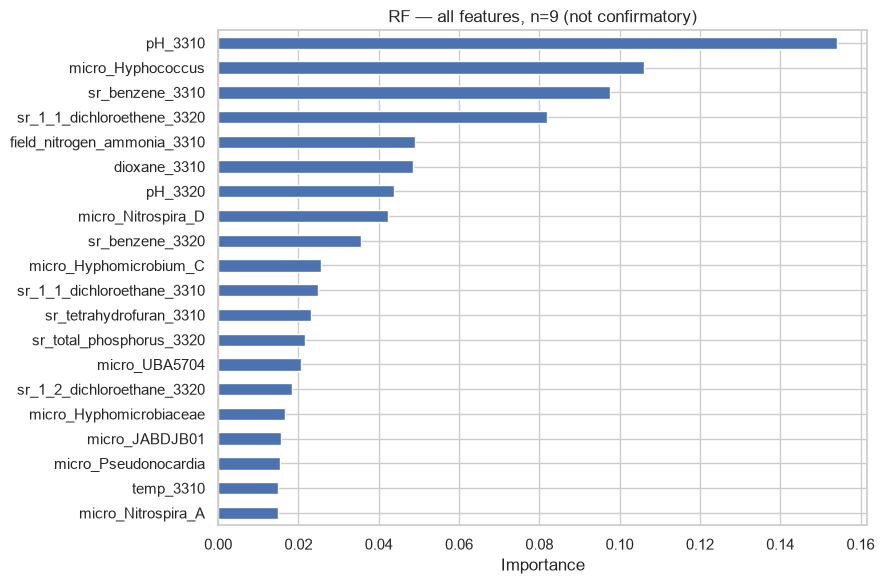

In [6]:
from sklearn.impute import SimpleImputer

df_rf = integrated.dropna(subset=[Y_COL]).copy()
X_df = df_rf[X_COLS].copy()
y = df_rf[Y_COL].values
n = len(df_rf)

print(f"RF rows: {n}, features: {X_df.shape[1]} (median imputation for sparse cols)")

if n < 4:
    print("Too few rows for RF — skip.")
else:
    imp = SimpleImputer(strategy="median")
    X_imp = imp.fit_transform(X_df)

    loo = LeaveOneOut()
    preds = np.zeros(n)
    model = RandomForestRegressor(
        n_estimators=200,
        max_depth=3,
        min_samples_leaf=2,
        random_state=42,
    )
    for train_idx, test_idx in loo.split(X_imp):
        model.fit(X_imp[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X_imp[test_idx])

    print(f"LOO R²: {r2_score(y, preds):.3f}")
    print(f"LOO MAE: {mean_absolute_error(y, preds):.4f} % points")

    model.fit(X_imp, y)
    imp_series = pd.Series(model.feature_importances_, index=X_df.columns).sort_values(
        ascending=False
    )
    print("\nTop 25 feature importances (exploratory only):")
    print(imp_series.head(25).to_string())

    top_imp = imp_series.head(20)
    fig, ax = plt.subplots(figsize=(9, 6))
    top_imp.sort_values().plot(kind="barh", ax=ax)
    ax.set_xlabel("Importance")
    ax.set_title(f"RF — all features, n={n} (not confirmatory)")
    plt.tight_layout()
    plt.show()

## Summary

- **X:** 3310/3320 influent + blend chemistry/field + microbes only.
- **3340 effluent:** kept in CSV for reference; **excluded from RF** (outcome side / leakage).
- **n=9** integrated dates — exploratory RF only; flat removal Y.
- **Next:** more co-sampled dates; per-reactor Y at 3331/3332/3333.